In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms
from torchinfo import summary
import torchmetrics

import requests
import zipfile
from pathlib import Path
import os

from timeit import default_timer

import random

import matplotlib.pyplot as plt
from PIL import Image
from pprint import pprint

import numpy as np
import pandas as pd

from src.data_helpers import walk_through_dir
from src.models import ImageClassCNN
from src.plotting_helpers import plot_transformed_images, plot_curves
from src.ml_helpers import train, get_training_time, pred_and_plot

In [2]:
# Device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cpu


In [3]:
# Get data - subset of Food 101 dataset
# This dataset uses only 3/101 classes and 10% of images (~75 training, ~25 testing)
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"
if image_path.is_dir():
  print(f"{image_path} dir already exists... skipping")
else:
  print(f"{image_path} dir doesn't exists... creating")
  image_path.mkdir(parents=True, exist_ok=True)

with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
  request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
  print("Downloading data...")
  f.write(request.content)

with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
  print("Unzipping...")
  zip_ref.extractall(image_path)

data\pizza_steak_sushi dir already exists... skipping
Unzipping...


In [4]:
# Inspect data directory structure
walk_through_dir(image_path)

There are 2 directories and 0 images in data\pizza_steak_sushi
There are 3 directories and 0 images in data\pizza_steak_sushi\test
There are 0 directories and 25 images in data\pizza_steak_sushi\test\pizza
There are 0 directories and 19 images in data\pizza_steak_sushi\test\steak
There are 0 directories and 31 images in data\pizza_steak_sushi\test\sushi
There are 3 directories and 0 images in data\pizza_steak_sushi\train
There are 0 directories and 78 images in data\pizza_steak_sushi\train\pizza
There are 0 directories and 75 images in data\pizza_steak_sushi\train\steak
There are 0 directories and 72 images in data\pizza_steak_sushi\train\sushi


In [5]:
# Setup train and test paths
train_dir = image_path / "train"
test_dir = image_path / "test"

Random image path: data\pizza_steak_sushi\test\pizza\416067.jpg
Class: pizza
Height: 512
Width: 512



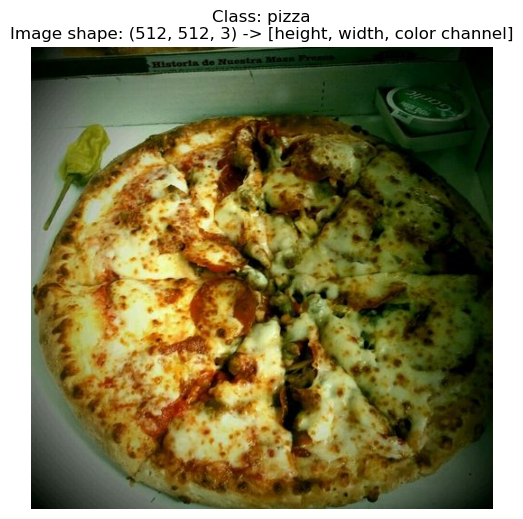

In [6]:
# Visualize the data
# Get all of the image paths
image_path_list = list(image_path.glob("*/*/*.jpg"))

# Select a random image path
random_image_path = random.choice(image_path_list)
print(f"Random image path: {random_image_path}")

# Get image class from path name
image_class = random_image_path.parent.stem
print(f"Class: {image_class}")

# Open image
img = Image.open(random_image_path)

print(f"Height: {img.height}")
print(f"Width: {img.width}")

print()

# Visualizing using matplotlib
img_as_array = np.asarray(img)
plt.figure(figsize=(8, 6))
plt.imshow(img_as_array)
plt.title(f"Class: {image_class}\nImage shape: {img_as_array.shape} -> [height, width, color channel]")
plt.axis(False)
plt.show()

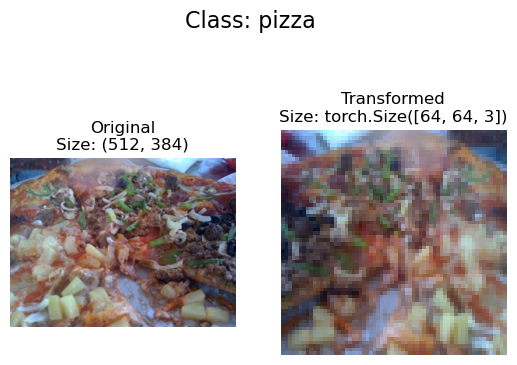

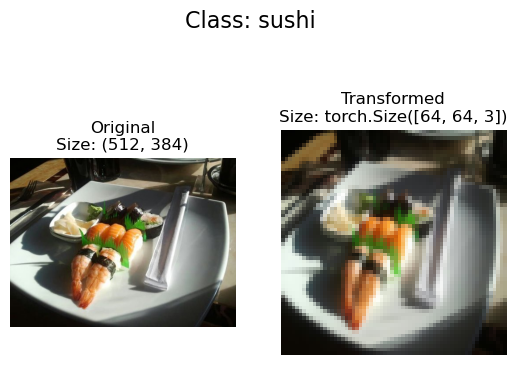

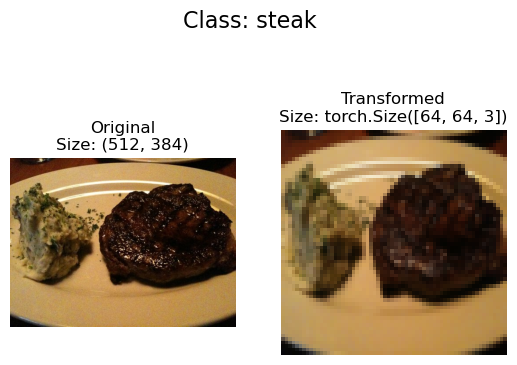

In [7]:
# Data augmentation - artificially increase diversity of the dataset
# => model that is more generalizable to unseen data

# Transforming data:
INPUT_IMG_SIZE = 64
data_transform = transforms.Compose([ # used to chain transforms together
    # Resize to INPUT_IMG_SIZExINPUT_IMG_SIZE
    transforms.Resize(size=(INPUT_IMG_SIZE, INPUT_IMG_SIZE)),
    # Flip images randomly on the horizontal (with probability p)
    # one example of data augmentation technique
    transforms.RandomHorizontalFlip(p=0.5),
    # Turn image into a torch tensor
    transforms.ToTensor()
])

# Visualize some original and transformed images side by side
plot_transformed_images(image_paths=image_path_list, transform=data_transform, n=3)

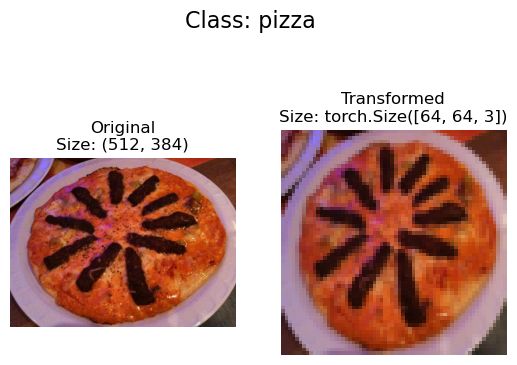

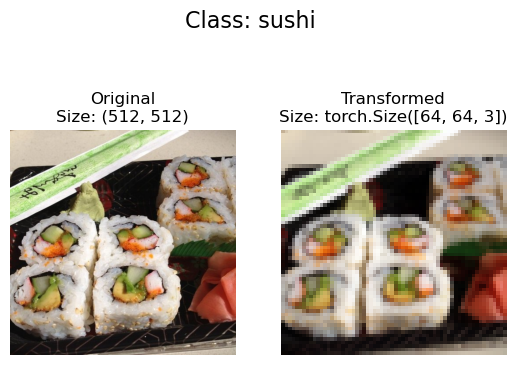

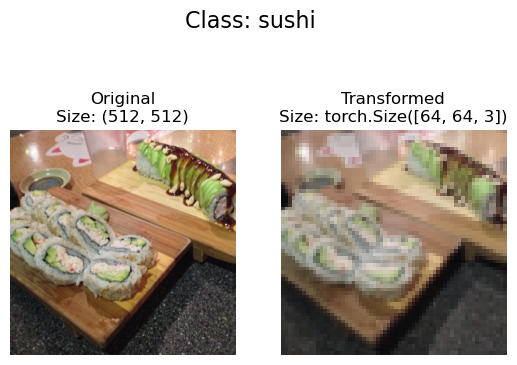

In [8]:
# Another example of data augmentation - TrivialAugmentWide
data_transform_trivial = transforms.Compose([
    transforms.Resize(size=(INPUT_IMG_SIZE, INPUT_IMG_SIZE)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31), # how intense of an augmentation do we want (0-31)
    transforms.ToTensor()
])

plot_transformed_images(image_paths=image_path_list, transform=data_transform_trivial, n=3, seed=None)

In [9]:
# Let's observe same model trained on data with and without augmentations

In [10]:
# 1. Simple model trained w/o augmented data
# Create simple transform - only resizing
simple_transform = transforms.Compose([
    transforms.Resize(size=(INPUT_IMG_SIZE, INPUT_IMG_SIZE)),
    transforms.ToTensor()
])

# Load data
train_data_simple = datasets.ImageFolder(root=train_dir, transform=simple_transform)
test_data_simple = datasets.ImageFolder(root=test_dir, transform=simple_transform)

# Create dataloaders
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()
train_dataloader_simple = DataLoader(dataset=train_data_simple,
                              batch_size=BATCH_SIZE,
                              shuffle=True,
                              num_workers=NUM_WORKERS
                              )
test_dataloader_simple = DataLoader(dataset=test_data_simple,
                             batch_size=BATCH_SIZE,
                             shuffle=False,
                             num_workers=NUM_WORKERS
                             )

In [11]:
# Get some information about dataset
CLASS_NAMES = train_data_simple.classes
print("Class names:")
pprint(CLASS_NAMES)

NUM_CLASSES = len(CLASS_NAMES)
print(f"Number of classes: {NUM_CLASSES}")

class_dict = train_data_simple.class_to_idx
print("Class names and labels dict:")
pprint(class_dict)

image, label = train_data_simple[0]
COLOR_CHANS, HEIGHT, WIDTH = image.shape
print(f"\nImage height: {HEIGHT}")
print(f"Image width: {WIDTH}")
print(f"Number of color channels: {COLOR_CHANS}")

Class names:
['pizza', 'steak', 'sushi']
Number of classes: 3
Class names and labels dict:
{'pizza': 0, 'steak': 1, 'sushi': 2}

Image height: 64
Image width: 64
Number of color channels: 3


In [12]:
torch.manual_seed(16)
torch.cuda.manual_seed(16)

model_simple = ImageClassCNN(
    input_shape=COLOR_CHANS,
    hidden_units=10,
    output_shape=NUM_CLASSES,
    img_height=HEIGHT,
    img_width=WIDTH
).to(device)

# Get info from a model using torchinfo
summary(
    model_simple,
    input_size=[BATCH_SIZE, COLOR_CHANS, HEIGHT, WIDTH] # example of data that will go through our model
)

Layer (type:depth-idx)                   Output Shape              Param #
ImageClassCNN                            [32, 3]                   --
﷿﷿﷿﷿﷿﷿Sequential: 1-1                        [32, 10, 32, 32]          --
﷿﷿﷿    ﷿﷿﷿﷿﷿﷿Conv2d: 2-1                       [32, 10, 64, 64]          280
﷿﷿﷿    ﷿﷿﷿﷿﷿﷿ReLU: 2-2                         [32, 10, 64, 64]          --
﷿﷿﷿    ﷿﷿﷿﷿﷿﷿Conv2d: 2-3                       [32, 10, 64, 64]          910
﷿﷿﷿    ﷿﷿﷿﷿﷿﷿ReLU: 2-4                         [32, 10, 64, 64]          --
﷿﷿﷿    ﷿﷿﷿﷿﷿﷿MaxPool2d: 2-5                    [32, 10, 32, 32]          --
﷿﷿﷿﷿﷿﷿Sequential: 1-2                        [32, 10, 16, 16]          --
﷿﷿﷿    ﷿﷿﷿﷿﷿﷿Conv2d: 2-6                       [32, 10, 32, 32]          910
﷿﷿﷿    ﷿﷿﷿﷿﷿﷿ReLU: 2-7                         [32, 10, 32, 32]          --
﷿﷿﷿    ﷿﷿﷿﷿﷿﷿Conv2d: 2-8                       [32, 10, 32, 32]          910
﷿﷿﷿    ﷿﷿﷿﷿﷿﷿ReLU: 2-9                         [32, 10, 32, 32]          --
﷿﷿﷿    ﷿﷿﷿﷿﷿﷿MaxPoo

In [13]:
# 2. Model with trained with augmented data
train_transform_augmented = transforms.Compose([
    transforms.Resize(size=(INPUT_IMG_SIZE, INPUT_IMG_SIZE)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

# No need to augment test set - still use simple_transform

# Load data
train_data_augmented = datasets.ImageFolder(
    root=train_dir,
    transform=train_transform_augmented
)
test_data_augmented = datasets.ImageFolder(
    root=test_dir,
    transform=simple_transform
)

# Create dataloaders
train_dataloader_augmented = DataLoader(
    dataset=train_data_augmented,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)
test_dataloader_augmented = DataLoader(
    dataset=test_data_augmented,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

In [14]:
torch.manual_seed(16)
torch.cuda.manual_seed(16)

model_augmented = ImageClassCNN(
    input_shape=COLOR_CHANS,
    hidden_units=10,
    output_shape=NUM_CLASSES,
    img_height=HEIGHT,
    img_width=WIDTH
).to(device)

# Get info from a model using torchinfo
summary(
    model_augmented,
    input_size=[BATCH_SIZE, COLOR_CHANS, HEIGHT, WIDTH] # example of data that will go through our model
)

Layer (type:depth-idx)                   Output Shape              Param #
ImageClassCNN                            [32, 3]                   --
﷿﷿﷿﷿﷿﷿Sequential: 1-1                        [32, 10, 32, 32]          --
﷿﷿﷿    ﷿﷿﷿﷿﷿﷿Conv2d: 2-1                       [32, 10, 64, 64]          280
﷿﷿﷿    ﷿﷿﷿﷿﷿﷿ReLU: 2-2                         [32, 10, 64, 64]          --
﷿﷿﷿    ﷿﷿﷿﷿﷿﷿Conv2d: 2-3                       [32, 10, 64, 64]          910
﷿﷿﷿    ﷿﷿﷿﷿﷿﷿ReLU: 2-4                         [32, 10, 64, 64]          --
﷿﷿﷿    ﷿﷿﷿﷿﷿﷿MaxPool2d: 2-5                    [32, 10, 32, 32]          --
﷿﷿﷿﷿﷿﷿Sequential: 1-2                        [32, 10, 16, 16]          --
﷿﷿﷿    ﷿﷿﷿﷿﷿﷿Conv2d: 2-6                       [32, 10, 32, 32]          910
﷿﷿﷿    ﷿﷿﷿﷿﷿﷿ReLU: 2-7                         [32, 10, 32, 32]          --
﷿﷿﷿    ﷿﷿﷿﷿﷿﷿Conv2d: 2-8                       [32, 10, 32, 32]          910
﷿﷿﷿    ﷿﷿﷿﷿﷿﷿ReLU: 2-9                         [32, 10, 32, 32]          --
﷿﷿﷿    ﷿﷿﷿﷿﷿﷿MaxPoo

In [15]:
# Define loss, optimizer and metrics
loss_func = nn.CrossEntropyLoss()

optimizer_simple = torch.optim.Adam(params=model_simple.parameters(), lr=0.001)
optimizer_augmented = torch.optim.Adam(params=model_augmented.parameters(), lr=0.001)

metrics = torchmetrics.classification.MulticlassAccuracy(num_classes=NUM_CLASSES).to(device)

In [16]:
# Train simple model
torch.manual_seed(42)
torch.cuda.manual_seed(42)
EPOCHS = 10

train_time_start_simple = default_timer()

model_simple_results = train(
    model=model_simple,
    train_dataloader=train_dataloader_simple,
    test_dataloader=test_dataloader_simple,
    optimizer=optimizer_simple,
    accuracy_func=metrics,
    loss_func=loss_func,
    epochs=EPOCHS,
    device = device
)

train_time_end_simple = default_timer()

total_train_time_simple = get_training_time(
    start_time=train_time_start_simple,
    end_time=train_time_end_simple,
    device=device
)

  0%|          | 0/10 [00:00<?, ?it/s]


Epoch: 0
--------------------------
Train loss: 1.1059 | Train accuracy: 0.0833
Test loss: 1.0965 | Test accuracy: 0.1531

Epoch: 1
--------------------------
Train loss: 1.0905 | Train accuracy: 0.2574
Test loss: 1.1077 | Test accuracy: 0.1302

Epoch: 2
--------------------------
Train loss: 1.0855 | Train accuracy: 0.2253
Test loss: 1.1229 | Test accuracy: 0.1302

Epoch: 3
--------------------------
Train loss: 1.1081 | Train accuracy: 0.1016
Test loss: 1.1290 | Test accuracy: 0.1302

Epoch: 4
--------------------------
Train loss: 1.0863 | Train accuracy: 0.2071
Test loss: 1.1206 | Test accuracy: 0.2668

Epoch: 5
--------------------------
Train loss: 1.0574 | Train accuracy: 0.4310
Test loss: 1.1145 | Test accuracy: 0.1942

Epoch: 6
--------------------------
Train loss: 0.9582 | Train accuracy: 0.6096
Test loss: 1.0904 | Test accuracy: 0.2778

Epoch: 7
--------------------------
Train loss: 0.9513 | Train accuracy: 0.6497
Test loss: 1.0546 | Test accuracy: 0.3838

Epoch: 8
------

In [17]:
# Train augmented data model
torch.manual_seed(42)
torch.cuda.manual_seed(42)

train_time_start_augmented = default_timer()

model_augmented_results = train(
    model=model_augmented,
    train_dataloader=train_dataloader_augmented,
    test_dataloader=test_dataloader_augmented,
    optimizer=optimizer_augmented,
    accuracy_func=metrics,
    loss_func=loss_func,
    epochs=EPOCHS,
    device = device
)

train_time_end_augmented = default_timer()

total_train_time_augmented = get_training_time(
    start_time=train_time_start_augmented,
    end_time=train_time_end_augmented,
    device=device
)

  0%|          | 0/10 [00:00<?, ?it/s]


Epoch: 0
--------------------------
Train loss: 1.1054 | Train accuracy: 0.0833
Test loss: 1.0968 | Test accuracy: 0.1984

Epoch: 1
--------------------------
Train loss: 1.0899 | Train accuracy: 0.2517
Test loss: 1.1077 | Test accuracy: 0.1302

Epoch: 2
--------------------------
Train loss: 1.0845 | Train accuracy: 0.2676
Test loss: 1.1204 | Test accuracy: 0.1302

Epoch: 3
--------------------------
Train loss: 1.0792 | Train accuracy: 0.3346
Test loss: 1.1332 | Test accuracy: 0.2229

Epoch: 4
--------------------------
Train loss: 1.0559 | Train accuracy: 0.3813
Test loss: 1.1241 | Test accuracy: 0.2402

Epoch: 5
--------------------------
Train loss: 1.0774 | Train accuracy: 0.2933
Test loss: 1.1101 | Test accuracy: 0.2833

Epoch: 6
--------------------------
Train loss: 0.9768 | Train accuracy: 0.5847
Test loss: 1.0646 | Test accuracy: 0.3833

Epoch: 7
--------------------------
Train loss: 1.0328 | Train accuracy: 0.6375
Test loss: 1.0548 | Test accuracy: 0.4095

Epoch: 8
------

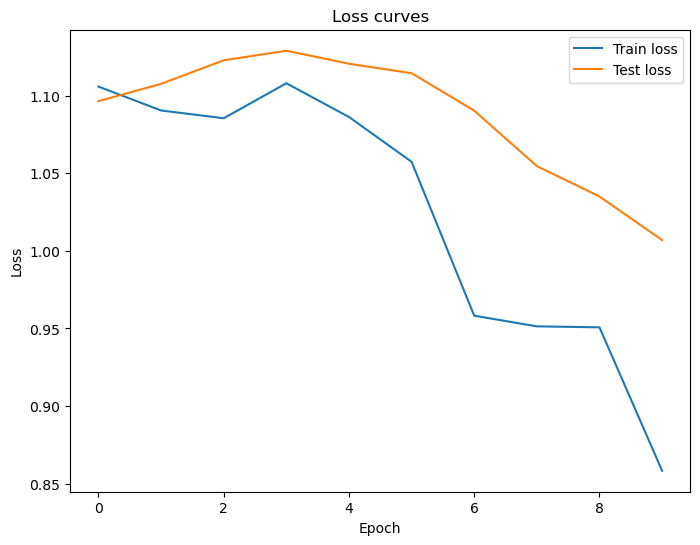

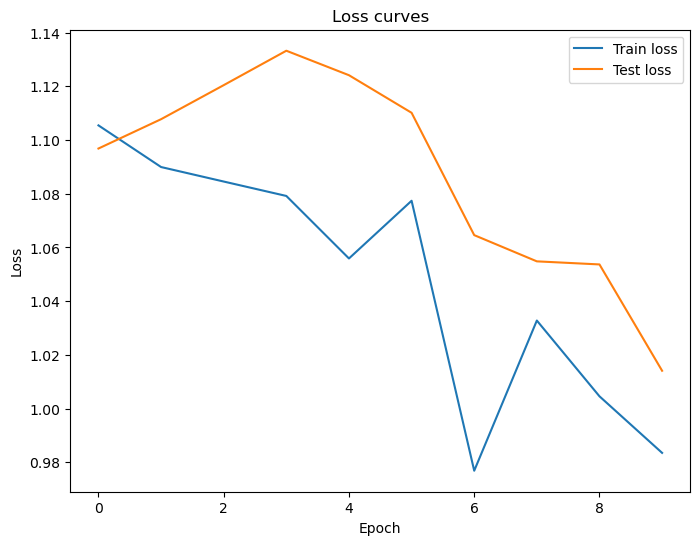

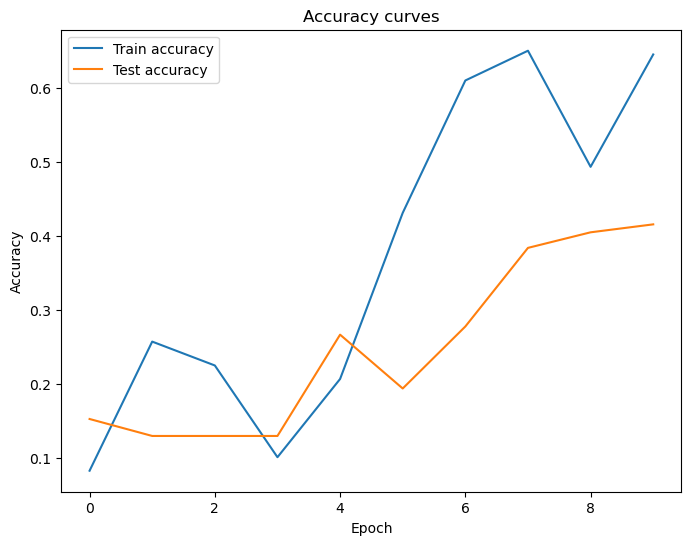

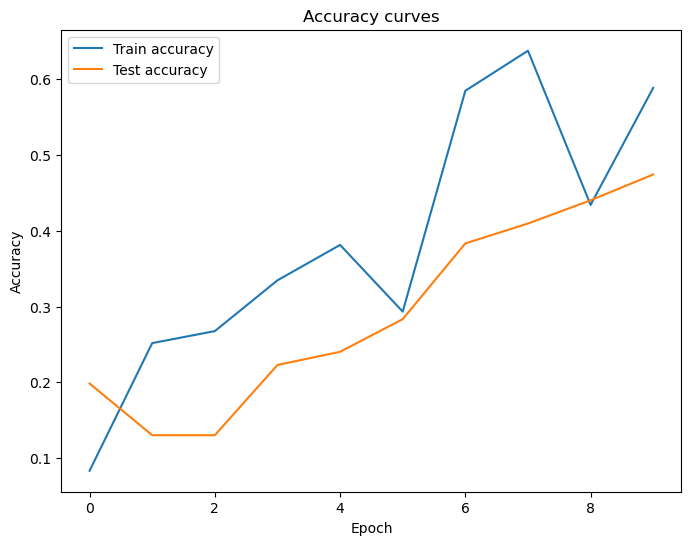

In [18]:
# Plot model losses and accuracies
epoch_range = range(EPOCHS)
plot_curves(epoch_range, model_simple_results["train_loss"], model_simple_results["test_loss"], var_to_plot="loss", filename="model_simple_loss.png")
plot_curves(epoch_range, model_augmented_results["train_loss"], model_augmented_results["test_loss"], var_to_plot="loss", filename="model_augmented_loss.png")

plot_curves(epoch_range, model_simple_results["train_acc"], model_simple_results["test_acc"], var_to_plot="accuracy", filename="model_simple_acc.png")
plot_curves(epoch_range, model_augmented_results["train_acc"], model_augmented_results["test_acc"], var_to_plot="accuracy", filename="model_augmented_acc.png")

   train_loss  train_acc  test_loss  test_acc
0    1.105905   0.083333   1.096535  0.153086
1    1.090503   0.257440   1.107669  0.130208
2    1.085485   0.225260   1.122852  0.130208
3    1.108054   0.101563   1.129025  0.130208
4    1.086303   0.207059   1.120643  0.266801
5    1.057410   0.431032   1.114535  0.194231
6    0.958194   0.609575   1.090382  0.277841
7    0.951318   0.649697   1.054641  0.383838
8    0.950693   0.493126   1.035045  0.404824
9    0.858248   0.644651   1.006945  0.415555
   train_loss  train_acc  test_loss  test_acc
0    1.105438   0.083333   1.096819  0.198413
1    1.089927   0.251736   1.107744  0.130208
2    1.084527   0.267557   1.120420  0.130208
3    1.079159   0.334580   1.133241  0.222884
4    1.055881   0.381290   1.124120  0.240245
5    1.077370   0.293302   1.110127  0.283333
6    0.976841   0.584708   1.064569  0.383294
7    1.032765   0.637545   1.054807  0.409509
8    1.004553   0.434081   1.053659  0.440212
9    0.983488   0.588590   1.01407

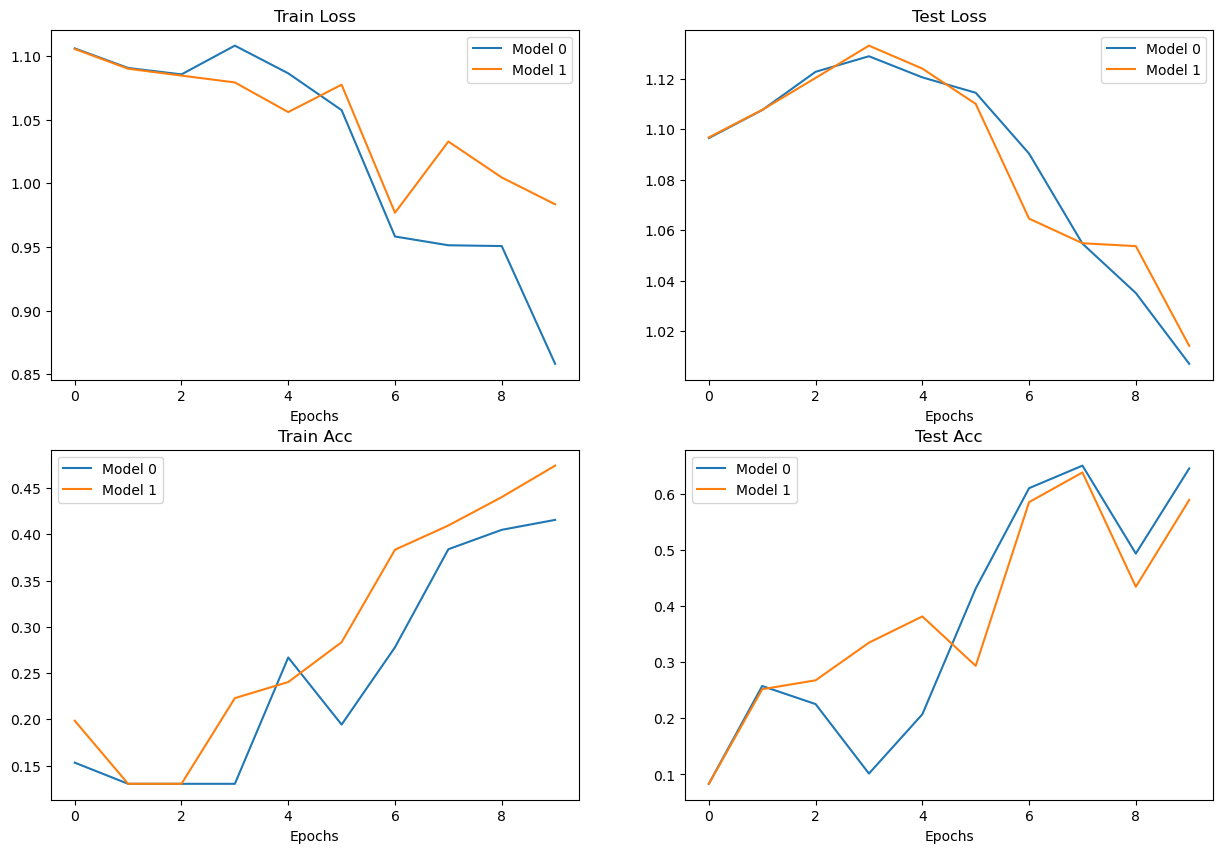

In [21]:
# Comparing models to eachother
model_simple_df = pd.DataFrame(model_simple_results)
model_augmented_df = pd.DataFrame(model_augmented_results)

print(model_simple_df)
print(model_augmented_df)

plt.figure(figsize=(15,10))

plt.subplot(2, 2, 1)
plt.plot(epoch_range, model_simple_df["train_loss"], label="Model 0")
plt.plot(epoch_range, model_augmented_df["train_loss"], label="Model 1")
plt.title("Train Loss")
plt.xlabel("Epochs")
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(epoch_range, model_simple_df["test_loss"], label="Model 0")
plt.plot(epoch_range, model_augmented_df["test_loss"], label="Model 1")
plt.title("Test Loss")
plt.xlabel("Epochs")
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(epoch_range, model_simple_df["test_acc"], label="Model 0")
plt.plot(epoch_range, model_augmented_df["test_acc"], label="Model 1")
plt.title("Train Acc")
plt.xlabel("Epochs")
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(epoch_range, model_simple_df["train_acc"], label="Model 0")
plt.plot(epoch_range, model_augmented_df["train_acc"], label="Model 1")
plt.title("Test Acc")
plt.xlabel("Epochs")
plt.legend()

plt.savefig("model_curves_comparison.png")

plt.show()

In [ ]:
# Trend is generally in the right direction but model should be trained on larger dataset and the fine-tuned

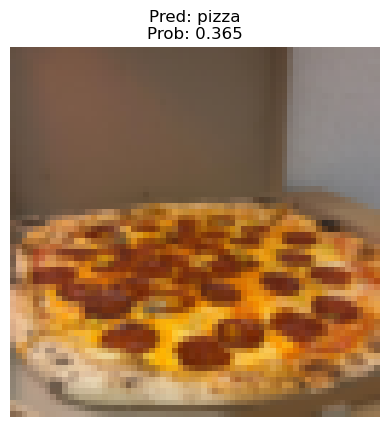

In [20]:
# Let's try predicting data on a custom image
custom_image_path = data_path / "pizza_img.jpeg"

# This image needs to be transformed so it's in the same format as data the model was trained on
custom_image_transform = transforms.Compose([transforms.Resize(size=(INPUT_IMG_SIZE, INPUT_IMG_SIZE))])

pred_and_plot(
    model=model_augmented,
    image_path=custom_image_path,
    class_names=CLASS_NAMES,
    transform=custom_image_transform,
    device=device,
    filename="example_custom_prediction.png"
)